# Neural Networks in Keras

In [62]:
import numpy as np
import pandas as pd
import polars as pl
import polars.selectors as ps
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, precision_recall_curve, roc_auc_score, roc_curve, accuracy_score
from sklearn.ensemble import RandomForestClassifier

from keras.models  import Sequential
from keras.layers import Input, Dense, Flatten, Dropout, BatchNormalization
from keras.optimizers import Adam, SGD, RMSprop

In this notebook we'll build a neural network with Keras. The goal is to predict whether a patient has a risk of diabetes based on several medical metrics:

1. Number of times pregnant
2. Plasma glucose concentration a 2 hours in an oral glucose tolerance test
3. Diastolic blood pressure (mm Hg)
4. Triceps skin fold thickness (mm)
5. 2-Hour serum insulin (mu U/ml)
6. Body mass index (weight in kg/(height in m)^2)
7. Diabetes pedigree function
8. Age (years)
9. Class variable (0 or 1)

All values are numeric, either floating point or integer.

First we'll load the dataset and split the data into features and targets. Then we'll split by test/train set.

In [63]:
columns = ["times_pregnant", "glucose_tolerance_test", "blood_pressure", "skin_thickness", 
           "insulin", "bmi", "pedigree_function", "age", "has_diabetes"]
df = pl.read_csv("./data/diabetes.csv", new_columns=columns)
df.head()

times_pregnant,glucose_tolerance_test,blood_pressure,skin_thickness,insulin,bmi,pedigree_function,age,has_diabetes
i64,i64,i64,i64,i64,f64,f64,i64,i64
6,148,72,35,0,33.6,0.627,50,1
1,85,66,29,0,26.6,0.351,31,0
8,183,64,0,0,23.3,0.672,32,1
1,89,66,23,94,28.1,0.167,21,0
0,137,40,35,168,43.1,2.288,33,1


There are 768 datapoints in 9 columns. Below the datatypes for each column are shown:

In [64]:
df.shape, list(zip(df.columns, df.dtypes))

((768, 9),
 [('times_pregnant', Int64),
  ('glucose_tolerance_test', Int64),
  ('blood_pressure', Int64),
  ('skin_thickness', Int64),
  ('insulin', Int64),
  ('bmi', Float64),
  ('pedigree_function', Float64),
  ('age', Int64),
  ('has_diabetes', Int64)])

In [65]:
target = "has_diabetes"
X = df.drop(target).to_numpy()
y = df.select(target).to_numpy().flatten()

In [66]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

## Random Forest Baseline

We'll use a simple model to get a reference baseline performance to beat. Often classical models are better than neural networks in performance, efficiency and even prediction quality. So it is always good to have an easily verifiable baseline to compare model performance with.

In [67]:
rf_model = RandomForestClassifier(n_estimators=200)
rf_model.fit(X_train, y_train)

# Get class prediction for each sample
y_pred_class_rf = rf_model.predict(X_test)
# Get probability for each class for each sample
# Has shape (n, 2), where n is the amount of samples and the 2
# indicates the two classes; 0: no diabetes, 1: diabetes
y_pred_prob_rf = rf_model.predict_proba(X_test)

print(f'accuracy is {accuracy_score(y_test, y_pred_class_rf):.3f}')
print(f'roc-auc is {roc_auc_score(y_test, y_pred_prob_rf[:,1]):.3f}')

accuracy is 0.745
roc-auc is 0.814


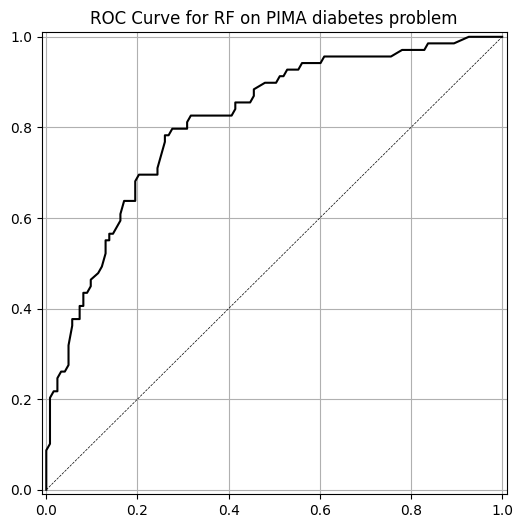

In [68]:
def plot_roc(y_test, y_pred, model_name):
    fpr, tpr, thr = roc_curve(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.plot(fpr, tpr, 'k-')
    ax.plot([0, 1], [0, 1], 'k--', linewidth=.5)  # roc curve for random model
    ax.grid(True)
    ax.set(title='ROC Curve for {} on PIMA diabetes problem'.format(model_name),
           xlim=[-0.01, 1.01], ylim=[-0.01, 1.01])
plot_roc(y_test, y_pred_prob_rf[:, 1], 'RF')

## Single layer Neural Network

Now we can use a simple sequential model to see if we can match the performance of the simple forest model. The input shape will be 8, since we have 8 features. The hidden layer will have a size of 12, and the output will be of size 1. This will output a probability of belonging to class 1, as is common for a binary classification problem.

In [69]:
normalizer = StandardScaler()
X_train_norm = normalizer.fit_transform(X_train)
X_test_norm = normalizer.transform(X_test)

In [70]:
INPUT_SIZE = 8
HIDDEN_SIZE = 12
OUTPUT_SIZE = 1
ACTIVATION = "sigmoid"

model_1 = Sequential()
model_1.add(Input((INPUT_SIZE, )))
model_1.add(Dense(HIDDEN_SIZE, activation=ACTIVATION))
model_1.add(Dense(OUTPUT_SIZE, activation=ACTIVATION))

model_1.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 12)             │           108 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            13 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121 (484.00 B)

 Trainable params: 121 (484.00 B)

 Non-trainable params: 0 (0.00 B)

As expected, there are 121 parameters. For the first layer, there are 8 inputs and 12 outputs, which would give 8X12=96, however, there is also a bias input which ups the parameter count to 9X12=108. The same argumant goes for the second layer with a size of (12+1)*1=13.

Adding these together gives: 108+13=121

Now we have a model set up, we can start training. The model needs to be compiled first, which will set it up with an optimizer, a loss function and an evalution metric.

In [71]:
model_1.compile(SGD(learning_rate=.003), "binary_crossentropy", metrics=["accuracy"])
run_hist_1 = model_1.fit(X_train_norm, y_train, validation_data=(X_test_norm, y_test), epochs=200)

Epoch 1/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6354 - loss: 0.6895 - val_accuracy: 0.6302 - val_loss: 0.6766
Epoch 2/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6424 - loss: 0.6870 - val_accuracy: 0.6250 - val_loss: 0.6746
Epoch 3/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6528 - loss: 0.6847 - val_accuracy: 0.6406 - val_loss: 0.6728
Epoch 4/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6528 - loss: 0.6826 - val_accuracy: 0.6354 - val_loss: 0.6712
Epoch 5/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6562 - loss: 0.6805 - val_accuracy: 0.6354 - val_loss: 0.6696
Epoch 6/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6545 - loss: 0.6786 - val_accuracy: 0.6354 - val_loss: 0.6681
Epoch 7/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6545 - loss: 0.6767 - val_accuracy: 0.6406 - val_loss: 0.6667
Epoch 8/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6545 - loss: 0.6750 - val_accuracy: 0.6406 - v

Again, we can make predictions in a similar way. The model only gives a single probability, which in this case corresponds with belonging to the 'has_diabetes' class. We can use these probabilities directly to plot our ROC graph. Then we can also use these probabilities to make direct class predictions.

In [72]:
y_pred_prob_nn_1 = model_1.predict(X_test_norm)
y_pred_class_nn_1 = (y_pred_prob_nn_1 > 0.5).astype(int)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


accuracy is 0.693
roc-auc is 0.776


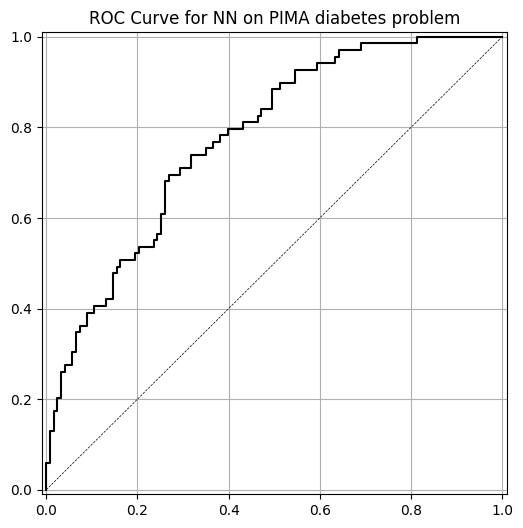

In [73]:
print('accuracy is {:.3f}'.format(accuracy_score(y_test,y_pred_class_nn_1)))
print('roc-auc is {:.3f}'.format(roc_auc_score(y_test,y_pred_prob_nn_1)))

plot_roc(y_test, y_pred_prob_nn_1, 'NN')

This is somewhat worse than the randomforest model earlier. Let's see if the training history can give some insight in what is going on. We can inspect the available metrics like this:

In [74]:
run_hist_1.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

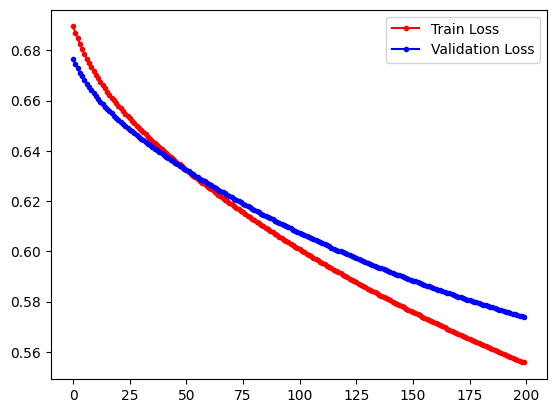

In [75]:
fig, ax = plt.subplots()
ax.plot(run_hist_1.history["loss"],'r', marker='.', label="Train Loss")
ax.plot(run_hist_1.history["val_loss"],'b', marker='.', label="Validation Loss")
ax.legend()

It looks like the training and validation are still going down, so the performance can improve by training for a bit longer. The model remembers where it is, so we can simply call tha train function again with an additional number of epochs.

Epoch 1/1000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7049 - loss: 0.5554 - val_accuracy: 0.6927 - val_loss: 0.5736
Epoch 2/1000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7066 - loss: 0.5550 - val_accuracy: 0.6927 - val_loss: 0.5734
Epoch 3/1000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7083 - loss: 0.5547 - val_accuracy: 0.6927 - val_loss: 0.5731
Epoch 4/1000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7101 - loss: 0.5543 - val_accuracy: 0.6927 - val_loss: 0.5728
Epoch 5/1000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7118 - loss: 0.5539 - val_accuracy: 0.6979 - val_loss: 0.5726
Epoch 6/1000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7135 - loss: 0.5536 - val_accuracy: 0.6979 - val_loss: 0.5723
Epoch 7/1000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7135 - loss: 0.5532 - val_accuracy: 0.6979 - val_loss: 0.5721
Epoch 8/1000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7135 - loss: 0.5529 - val_accuracy: 0.

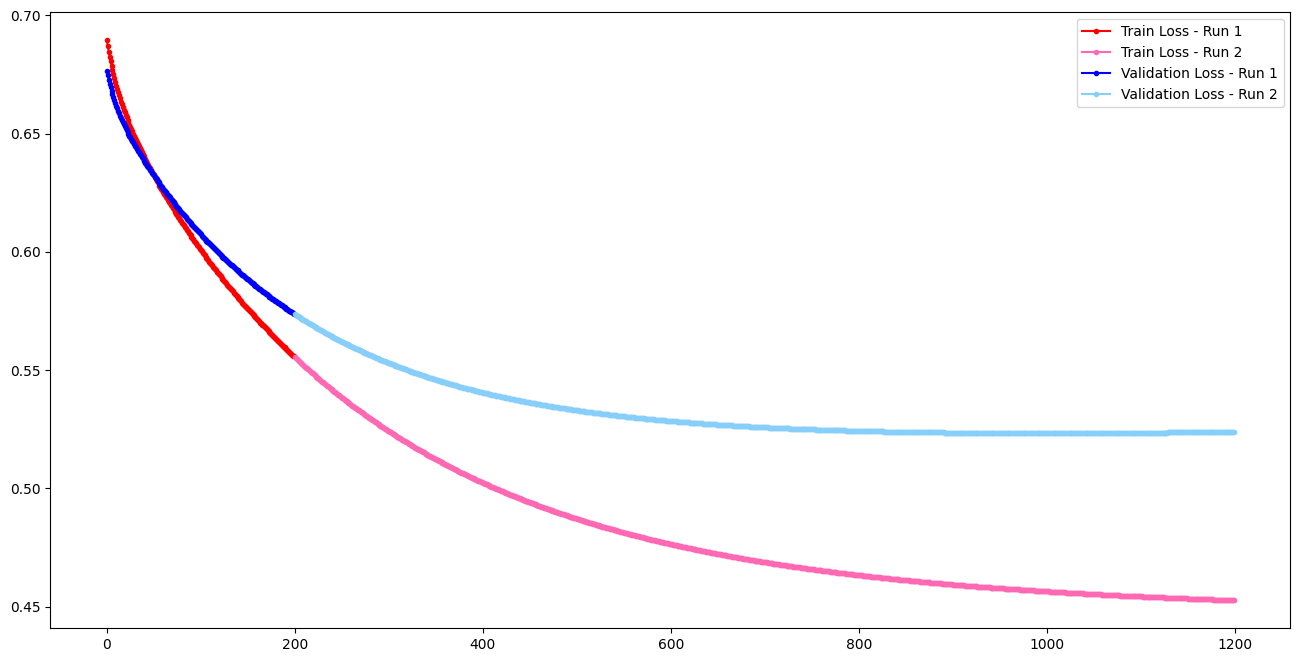

In [76]:
run_hist_1b = model_1.fit(X_train_norm, y_train, validation_data=(X_test_norm, y_test), epochs=1000)

n = len(run_hist_1.history["loss"])
m = len(run_hist_1b.history['loss'])
fig, ax = plt.subplots(figsize=(16, 8))

ax.plot(range(n), run_hist_1.history["loss"],'r', marker='.', label="Train Loss - Run 1")
ax.plot(range(n, n+m), run_hist_1b.history["loss"], 'hotpink', marker='.', label="Train Loss - Run 2")

ax.plot(range(n), run_hist_1.history["val_loss"],'b', marker='.', label="Validation Loss - Run 1")
ax.plot(range(n, n+m), run_hist_1b.history["val_loss"], 'LightSkyBlue', marker='.',  label="Validation Loss - Run 2")

ax.legend()

So clearly the model needed additional epochs before it saturated. It seems that around 800-1000 epochs the validation loss stabilises, which means the model could start overfitting on the training data after this points. Therefore this would be a good number to stop training.

## Another model

Neural networks have an enormous amount of freedom to choose hyperparameters. The choice in configuration of hidden layers alone is already extremely large, from the number of layers to the relative and absolute size, there is a lot of choice. Additionally, the choice of activation function, optimizer and evaluation metric also impact performance. 

Here we build a model with 2 hidden layers, the relu activation function within the network (to reduce the vanishing gradient problem) and the sigmoid activation function for the final layer (to ensure an output between 0 and 1).

In [77]:
INPUT_SIZE = 8
HIDDEN_SIZE_1 = 6
HIDDEN_SIZE_2 = 6
OUTPUT_SIZE = 1
ACTIVATION_HIDDEN = 'relu'
ACTIVATION_FINAL = 'sigmoid'
LR = 0.003
OPTIMIZER = SGD(learning_rate=LR)
LOSS_FN = "binary_crossentropy"
EVAL = ["accuracy"]
EPOCHS = 1500

model_2 = Sequential()
model_2.add(Input((INPUT_SIZE, )))
model_2.add(Dense(HIDDEN_SIZE_1, activation=ACTIVATION_HIDDEN))
model_2.add(Dense(HIDDEN_SIZE_2, activation=ACTIVATION_HIDDEN))
model_2.add(Dense(OUTPUT_SIZE, activation=ACTIVATION_FINAL))

model_2.compile(OPTIMIZER, LOSS_FN, metrics=EVAL)
run_hist_2 = model_2.fit(X_train_norm, y_train, validation_data=(X_test_norm, y_test), epochs=EPOCHS)

Epoch 1/1500
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3750 - loss: 0.8070 - val_accuracy: 0.4062 - val_loss: 0.7771
Epoch 2/1500
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3854 - loss: 0.7950 - val_accuracy: 0.4010 - val_loss: 0.7664
Epoch 3/1500
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3889 - loss: 0.7840 - val_accuracy: 0.4010 - val_loss: 0.7566
Epoch 4/1500
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3976 - loss: 0.7740 - val_accuracy: 0.4010 - val_loss: 0.7478
Epoch 5/1500
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4132 - loss: 0.7648 - val_accuracy: 0.4271 - val_loss: 0.7399
Epoch 6/1500
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4253 - loss: 0.7565 - val_accuracy: 0.4271 - val_loss: 0.7327
Epoch 7/1500
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4340 - loss: 0.7491 - val_accuracy: 0.4375 - val_loss: 0.7265
Epoch 8/1500
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4427 - loss: 0.7425 - val_accuracy: 0

We can again inspect the training history and use the following stored metrics:

In [78]:
run_hist_2.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

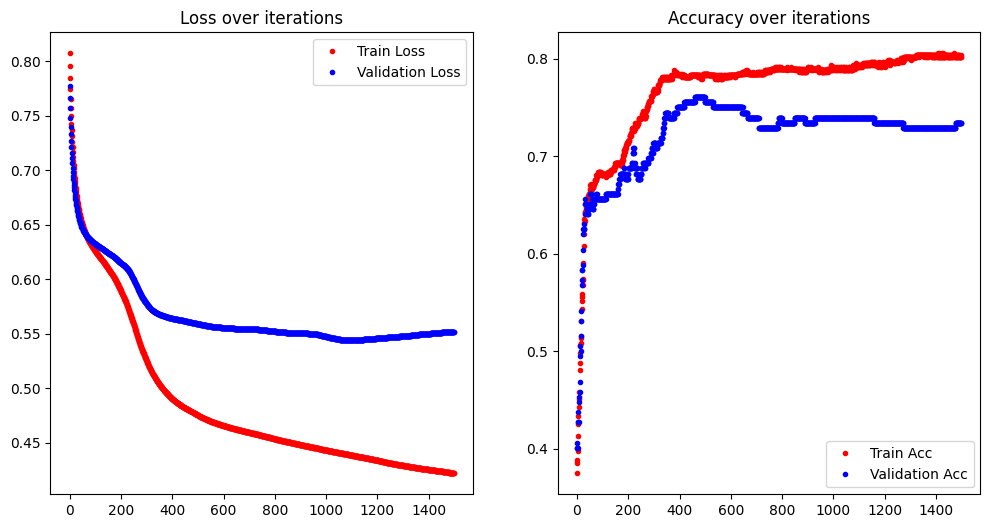

In [79]:
n = len(run_hist_2.history["loss"])

fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(1, 2, 1)
ax.plot(range(n), (run_hist_2.history["loss"]),'r.', label="Train Loss")
ax.plot(range(n), (run_hist_2.history["val_loss"]),'b.', label="Validation Loss")
ax.legend()
ax.set_title('Loss over iterations')

ax = fig.add_subplot(1, 2, 2)
ax.plot(range(n), (run_hist_2.history["accuracy"]),'r.', label="Train Acc")
ax.plot(range(n), (run_hist_2.history["val_accuracy"]),'b.', label="Validation Acc")
ax.legend(loc='lower right')
ax.set_title('Accuracy over iterations');

So this clearly trained for too long, the validation loss is going up after about 200 epochs, while the training loss still goes down, this is a clear sign of overfitting. We can stop after approximately 200 epochs.

In [80]:
INPUT_SIZE = 8
HIDDEN_SIZE_1 = 6
HIDDEN_SIZE_2 = 6
OUTPUT_SIZE = 1
ACTIVATION_HIDDEN = 'relu'
ACTIVATION_FINAL = 'sigmoid'
LR = 0.003
OPTIMIZER = SGD(learning_rate=LR)
LOSS_FN = "binary_crossentropy"
EVAL = ["accuracy"]
EPOCHS = 150

model_2 = Sequential()
model_2.add(Input((INPUT_SIZE, )))
model_2.add(Dense(HIDDEN_SIZE_1, activation=ACTIVATION_HIDDEN))
model_2.add(Dense(HIDDEN_SIZE_2, activation=ACTIVATION_HIDDEN))
model_2.add(Dense(OUTPUT_SIZE, activation=ACTIVATION_FINAL))

model_2.compile(OPTIMIZER, LOSS_FN, metrics=EVAL)
run_hist_2 = model_2.fit(X_train_norm, y_train, validation_data=(X_test_norm, y_test), epochs=EPOCHS)

Epoch 1/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3854 - loss: 0.9825 - val_accuracy: 0.3594 - val_loss: 1.0092
Epoch 2/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3854 - loss: 0.9383 - val_accuracy: 0.3594 - val_loss: 0.9709
Epoch 3/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3993 - loss: 0.9009 - val_accuracy: 0.3594 - val_loss: 0.9382
Epoch 4/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4219 - loss: 0.8689 - val_accuracy: 0.3646 - val_loss: 0.9101
Epoch 5/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4340 - loss: 0.8413 - val_accuracy: 0.3750 - val_loss: 0.8859
Epoch 6/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4427 - loss: 0.8175 - val_accuracy: 0.3490 - val_loss: 0.8652
Epoch 7/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4566 - loss: 0.7967 - val_accuracy: 0.3750 - val_loss: 0.8472
Epoch 8/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4653 - loss: 0.7789 - val_accuracy: 0.3802 - 

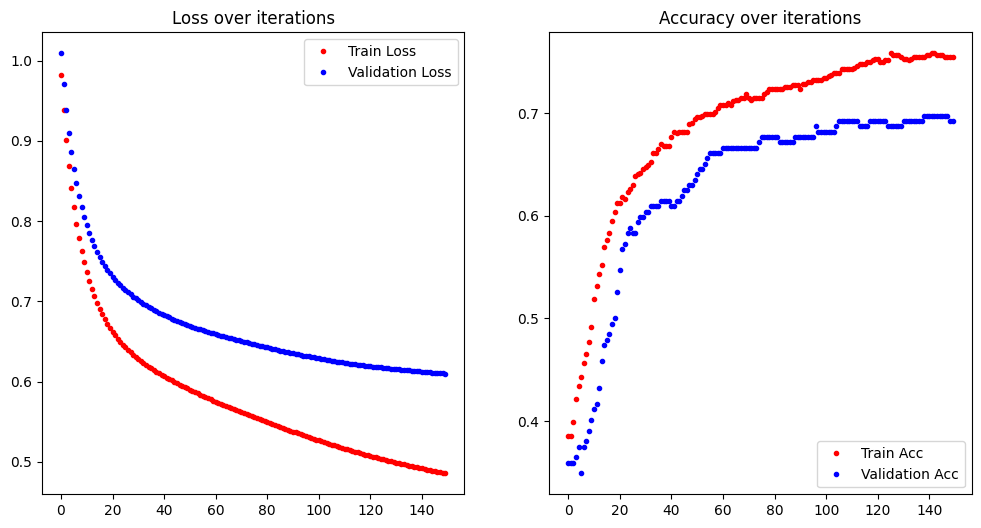

In [81]:
n = len(run_hist_2.history["loss"])

fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(1, 2, 1)
ax.plot(range(n), (run_hist_2.history["loss"]),'r.', label="Train Loss")
ax.plot(range(n), (run_hist_2.history["val_loss"]),'b.', label="Validation Loss")
ax.legend()
ax.set_title('Loss over iterations')

ax = fig.add_subplot(1, 2, 2)
ax.plot(range(n), (run_hist_2.history["accuracy"]),'r.', label="Train Acc")
ax.plot(range(n), (run_hist_2.history["val_accuracy"]),'b.', label="Validation Acc")
ax.legend(loc='lower right')
ax.set_title('Accuracy over iterations');

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 

accuracy is 0.693
roc-auc is 0.712


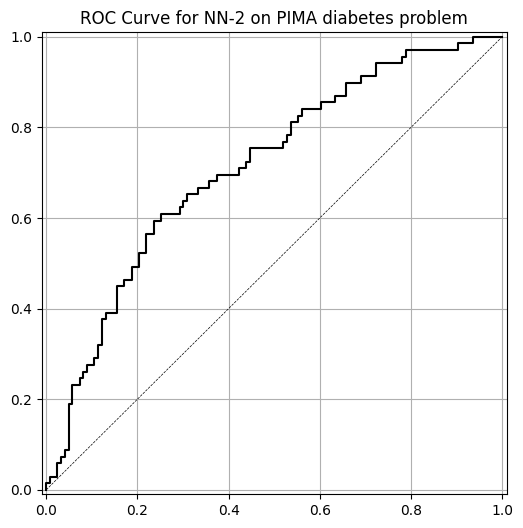

In [82]:
y_pred_prob_nn_2 = model_2.predict(X_test_norm)
y_pred_class_nn_2 = (y_pred_prob_nn_2 > 0.5).astype(int)
print('')
print(f'accuracy is {accuracy_score(y_test,y_pred_class_nn_2):.3f}')
print(f'roc-auc is {roc_auc_score(y_test,y_pred_prob_nn_2):.3f}')

plot_roc(y_test, y_pred_prob_nn_2, 'NN-2')